# 04. Feature 관점 이해 실습

## 학습 목표
1. Convolution Feature의 의미를 시각적으로 이해한다.
2. 고차원 데이터에서 Feature 공간을 해석하는 방법을 익힌다.
3. 센서 데이터 Feature Engineering 개념과 효과를 실습한다.

---

이 노트북은 앞선 `02_데이터셋_구축_EDA.ipynb`, `03_센서영상_문제정의_실습.ipynb`의 연장선입니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"

print("DATA_ROOT:", DATA_ROOT)
print("exists   :", DATA_ROOT.exists())

DATA_ROOT: C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset\pcb-defect-dataset
exists   : True


## 1) Convolution Feature 의미 해석

CNN은 필터(커널)를 통해 이미지에서 특징(feature)을 추출합니다.
- **저수준 feature**: 경계(edge), 방향성, 코너
- **중간 feature**: 반복 패턴, 결함 주변 질감
- **고수준 feature**: 클래스 구분에 유효한 형태적 단서

아래는 직접 만든 커널로 Feature Map을 시각화하는 실습입니다.

selected image: l_light_01_missing_hole_01_1_600.jpg (600, 600)


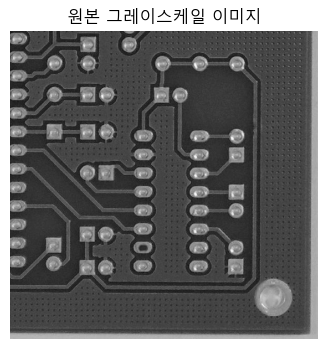

In [2]:
# 샘플 이미지 선택 (있으면 원본 stem 우선, 없으면 첫 이미지)
candidate_stems = [
    "light_01_missing_hole_01_1_256",
    "light_01_open_circuit_01_1_256",
    "light_01_short_01_1_256",
]

image_dir = DATA_ROOT / "train" / "images"
selected_path = None
for stem in candidate_stems:
    p = image_dir / f"{stem}.jpg"
    if p.exists():
        selected_path = p
        break

if selected_path is None:
    selected_path = sorted(image_dir.glob("*.jpg"))[0]

img = Image.open(selected_path).convert("L")
img_arr = np.array(img, dtype=np.float32) / 255.0
print("selected image:", selected_path.name, img_arr.shape)

plt.figure(figsize=(4, 4))
plt.imshow(img_arr, cmap="gray")
plt.title("원본 그레이스케일 이미지")
plt.axis("off")
plt.show()

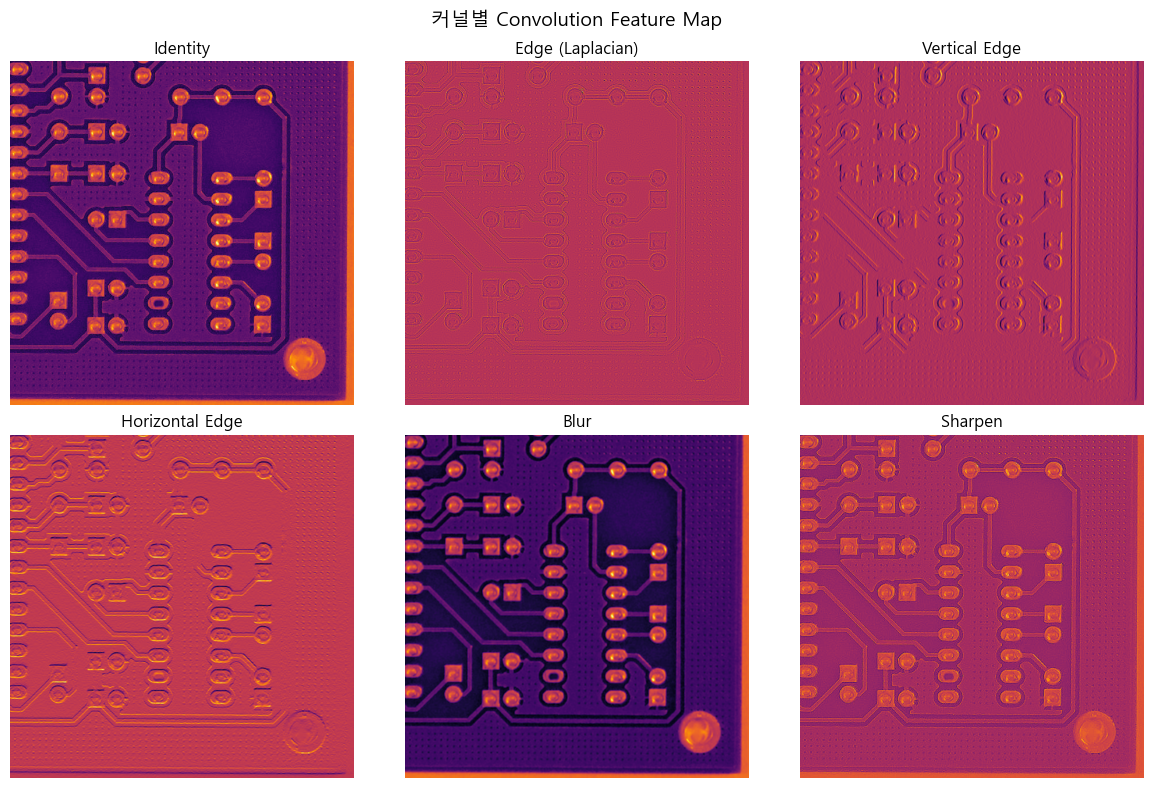

In [3]:
def conv2d_valid(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    h, w = image.shape
    kh, kw = kernel.shape
    oh, ow = h - kh + 1, w - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    k = np.flipud(np.fliplr(kernel))

    for i in range(oh):
        for j in range(ow):
            patch = image[i:i+kh, j:j+kw]
            out[i, j] = np.sum(patch * k)
    return out

# 대표 커널
kernels = {
    "Identity": np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
    "Edge (Laplacian)": np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32),
    "Vertical Edge": np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    "Horizontal Edge": np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32),
    "Blur": (1/9.0)*np.ones((3,3), dtype=np.float32),
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
}

feature_maps = {name: conv2d_valid(img_arr, ker) for name, ker in kernels.items()}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, fmap) in zip(axes.flatten(), feature_maps.items()):
    ax.imshow(fmap, cmap="inferno")
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("커널별 Convolution Feature Map", fontsize=14)
plt.tight_layout()
plt.show()

### 해석 포인트
- `Vertical/Horizontal Edge`는 배선 경계 변화가 큰 부분에서 반응이 큽니다.
- `Laplacian`은 결함 경계처럼 **급격한 변화**를 강조합니다.
- `Blur`는 노이즈를 줄이지만 미세 결함까지 약화시킬 수 있습니다.
- `Sharpen`은 세부 구조를 강화해 작은 결함을 더 도드라지게 만들 수 있습니다.

즉, **Feature는 원본 픽셀의 다른 표현 공간**이며, 모델은 이 공간에서 결함을 구분합니다.

## 2) 고차원 데이터 Feature 개념 이해

실무 모델 입력 Feature는 종종 수십~수백 차원입니다.
차원이 커질수록:
- 직관적 시각화가 어려워지고
- 거리/유사도 해석이 복잡해지며
- 불필요 Feature가 일반화 성능을 떨어뜨릴 수 있습니다.

아래 실습에서는 이미지에서 간단한 통계 Feature를 추출해 2D로 투영해 봅니다.

Feature matrix shape: (300, 7)


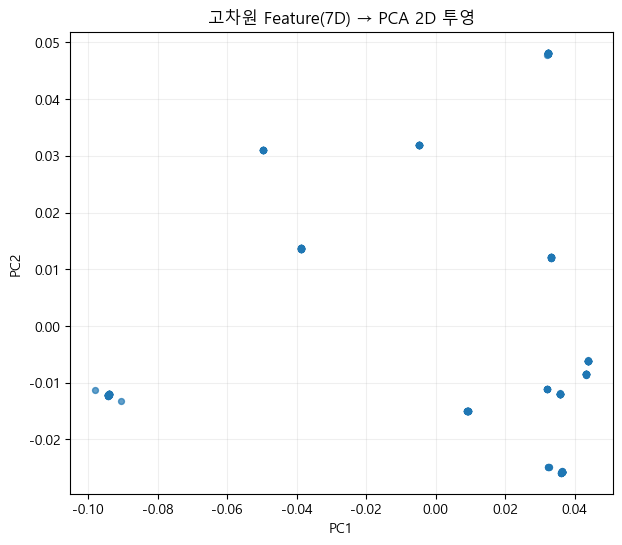

,count,mean,std,min,25%,50%,75%,max
mean,300.0,0.366899,0.018345,0.332800,0.360178,0.369737,0.377041,0.394416
std,300.0,0.123314,0.010596,0.106759,0.108606,0.123047,0.132538,0.138089
p10,300.0,0.237948,0.018438,0.219608,0.227451,0.235294,0.239216,0.290196
p50,300.0,0.344196,0.016083,0.321569,0.329412,0.341176,0.360784,0.372549
p90,300.0,0.551255,0.047267,0.462745,0.513726,0.568627,0.592157,0.592157
grad_energy,300.0,0.004204,0.000619,0.003066,0.003800,0.004175,0.004956,0.005027
edge_ratio,300.0,0.047993,0.007595,0.038044,0.043748,0.046447,0.049360,0.069566


In [4]:
def extract_basic_image_features(gray: np.ndarray) -> np.ndarray:
    # 간단하지만 해석 가능한 feature들
    mean = gray.mean()
    std = gray.std()
    p10, p50, p90 = np.percentile(gray, [10, 50, 90])

    # gradient 기반 특징
    gx = np.diff(gray, axis=1)
    gy = np.diff(gray, axis=0)
    grad_energy = (gx**2).mean() + (gy**2).mean()

    # edge-like 비율 (간이)
    edge_ratio = (np.abs(gx) > 0.1).mean()

    return np.array([mean, std, p10, p50, p90, grad_energy, edge_ratio], dtype=np.float32)

# 샘플 이미지 300장 feature 추출
sample_paths = sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))[:300]
X = []
names = []

for p in sample_paths:
    g = np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0
    X.append(extract_basic_image_features(g))
    names.append(p.stem)

X = np.vstack(X)
print("Feature matrix shape:", X.shape)  # (N, D)

# PCA (numpy SVD)
Xc = X - X.mean(axis=0, keepdims=True)
U, S, VT = np.linalg.svd(Xc, full_matrices=False)
Z = Xc @ VT[:2].T  # 2D projection

plt.figure(figsize=(7, 6))
plt.scatter(Z[:, 0], Z[:, 1], s=18, alpha=0.7)
plt.title("고차원 Feature(7D) → PCA 2D 투영")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()

feature_cols = ["mean", "std", "p10", "p50", "p90", "grad_energy", "edge_ratio"]
pd.DataFrame(X, columns=feature_cols).describe().T

## 3) 센서 데이터 Feature Engineering 개념 이해

원시 센서 값(raw signal)만 쓰기보다, 도메인 지식을 반영한 Feature를 설계하면
모델이 공정 상태를 더 잘 구분할 수 있습니다.

예시:
- Rolling mean / std
- 변화율(차분), 순간 기울기
- 이상치 점수(z-score)
- 주기성/주파수 관련 feature

In [5]:
# 센서 시계열 시뮬레이션 (조도/온도/진동)
rng = np.random.default_rng(7)
N = 600
t = np.arange(N)

lux = 1000 + 80*np.sin(2*np.pi*t/120) + rng.normal(0, 20, N)
temp = 24 + 0.002*t + 0.2*np.sin(2*np.pi*t/200) + rng.normal(0, 0.08, N)
vib = 0.05 + 0.01*np.sin(2*np.pi*t/50) + np.abs(rng.normal(0, 0.006, N))

sensor_df = pd.DataFrame({
    "t": t,
    "lux": lux,
    "temp": temp,
    "vibration": vib,
})

# 결함 이벤트(가상): 진동 급증 + 조도 급락 구간
sensor_df["defect_event"] = 0
sensor_df.loc[220:260, "defect_event"] = 1
sensor_df.loc[420:455, "defect_event"] = 1
sensor_df.loc[sensor_df["defect_event"] == 1, "vibration"] += 0.02
sensor_df.loc[sensor_df["defect_event"] == 1, "lux"] -= 90

sensor_df.head()

,t,lux,temp,vibration,defect_event
0,0,1000.024603,23.868843,0.058199,0
1,1,1010.161787,24.054736,0.052510,0
2,2,1002.879520,24.012147,0.055670,0
3,3,994.702920,24.049494,0.055894,0
4,4,1007.539520,23.897252,0.065267,0


In [6]:
# Feature Engineering
w = 15
fe = sensor_df.copy()

for c in ["lux", "temp", "vibration"]:
    fe[f"{c}_roll_mean"] = fe[c].rolling(w, min_periods=1).mean()
    fe[f"{c}_roll_std"] = fe[c].rolling(w, min_periods=1).std().fillna(0)
    fe[f"{c}_diff1"] = fe[c].diff().fillna(0)
    fe[f"{c}_zscore"] = (fe[c] - fe[c].mean()) / (fe[c].std() + 1e-8)

# 멀티센서 조합 feature
fe["lux_vib_ratio"] = fe["lux"] / (fe["vibration"] + 1e-6)
fe["temp_lux_interaction"] = fe["temp"] * fe["lux"]

engineered_cols = [
    "lux", "temp", "vibration",
    "lux_roll_mean", "lux_roll_std", "lux_diff1", "lux_zscore",
    "temp_roll_mean", "temp_roll_std", "temp_diff1", "temp_zscore",
    "vibration_roll_mean", "vibration_roll_std", "vibration_diff1", "vibration_zscore",
    "lux_vib_ratio", "temp_lux_interaction",
]

print("원시+엔지니어링 feature 개수:", len(engineered_cols))
fe[engineered_cols + ["defect_event"]].head(8)

원시+엔지니어링 feature 개수: 17


,lux,temp,vibration,lux_roll_mean,lux_roll_std,lux_diff1,lux_zscore,temp_roll_mean,temp_roll_std,temp_diff1,temp_zscore,vibration_roll_mean,vibration_roll_std,vibration_diff1,vibration_zscore,lux_vib_ratio,temp_lux_interaction,defect_event
0,1000.024603,23.868843,0.058199,1000.024603,0.000000,0.000000,0.201286,23.868843,0.000000,0.000000,-2.109558,0.058199,0.000000,0.000000,0.053626,17182.510246,23869.430500,0
1,1010.161787,24.054736,0.052510,1005.093195,7.168072,10.137184,0.344486,23.961790,0.131446,0.185893,-1.571737,0.055355,0.004023,-0.005689,-0.540344,19237.180469,24299.175003,0
2,1002.879520,24.012147,0.055670,1004.355303,5.227244,-7.282267,0.241615,23.978575,0.097387,-0.042589,-1.694955,0.055460,0.002850,0.003160,-0.210396,18014.315631,24081.290333,0
3,994.702920,24.049494,0.055894,1001.942208,6.442684,-8.176600,0.126112,23.996305,0.087065,0.037348,-1.586902,0.055568,0.002337,0.000224,-0.187039,17795.925921,23922.102347,0
4,1007.539520,23.897252,0.065267,1003.061670,6.115318,12.836599,0.307443,23.976494,0.087450,-0.152243,-2.027367,0.057508,0.004786,0.009373,0.791487,15437.049285,24077.425696,0
5,1000.872593,24.012078,0.061221,1002.696824,5.542235,-6.666927,0.213265,23.982425,0.079555,0.114826,-1.695155,0.058127,0.004542,-0.004046,0.369127,16348.218901,24033.030530,0
6,1025.924232,24.001488,0.056968,1006.015025,10.132630,25.051639,0.567149,23.985148,0.072980,-0.010590,-1.725794,0.057961,0.004169,-0.004253,-0.074863,18008.327416,24623.707820,0
7,1055.473741,23.988492,0.063036,1012.197364,19.843729,29.549509,0.984570,23.985566,0.067577,-0.012996,-1.763394,0.058596,0.004256,0.006067,0.558589,16743.757282,25319.223050,0


이벤트 구분에 기여 가능성이 높은 feature Top 10


,normal_mean,defect_mean,abs_gap
lux_vib_ratio,18418.267958,12256.591359,6161.676599
temp_lux_interaction,24599.506974,21818.112334,2781.394641
lux,1001.489562,879.041586,122.447976
lux_roll_mean,999.862667,892.393220,107.469447
lux_roll_std,23.063668,32.704242,9.640573
vibration_zscore,-0.225418,1.531087,1.756505
lux_zscore,0.221981,-1.507739,1.729720
lux_diff1,0.098685,-0.985397,1.084081
temp_zscore,-0.097106,0.659565,0.756672
temp,24.564427,24.825963,0.261536


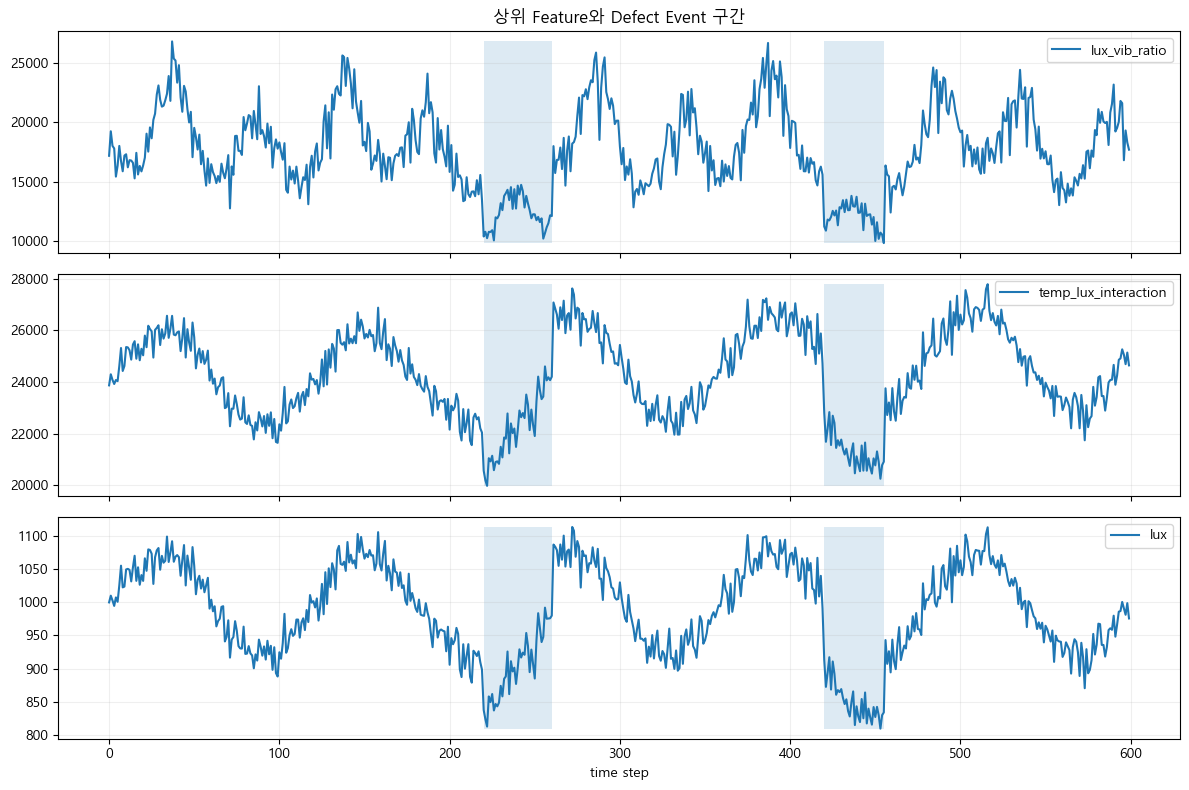

In [7]:
# Feature가 이벤트 구분에 주는 신호 확인
summary = fe.groupby("defect_event")[engineered_cols].mean().T
summary.columns = ["normal_mean", "defect_mean"]
summary["abs_gap"] = (summary["defect_mean"] - summary["normal_mean"]).abs()
summary = summary.sort_values("abs_gap", ascending=False)

print("이벤트 구분에 기여 가능성이 높은 feature Top 10")
display(summary.head(10))

# 시각화
top_feats = summary.head(3).index.tolist()
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for i, col in enumerate(top_feats):
    axes[i].plot(fe["t"], fe[col], label=col)
    axes[i].fill_between(fe["t"], fe[col].min(), fe[col].max(), where=fe["defect_event"]==1, alpha=0.15)
    axes[i].legend(loc="upper right")
    axes[i].grid(alpha=0.2)
axes[0].set_title("상위 Feature와 Defect Event 구간")
plt.xlabel("time step")
plt.tight_layout()
plt.show()

## 4) 고차원 Feature 실무 체크리스트

- Feature 의미가 현업 용어로 설명 가능한가?
- 센서 드리프트/노이즈에 robust한가?
- 라벨 누수(leakage)를 유발하지 않는가?
- 학습/서빙 시 동일 계산식으로 재현 가능한가?
- Feature 개수 증가 대비 성능 이득이 있는가?

> 핵심: **좋은 Feature는 성능 향상 + 해석 가능성 + 운영 안정성**을 동시에 만족합니다.

## 5) 실습 과제

1. Convolution 커널을 2개 추가해 Feature Map 변화를 비교하세요.
2. 이미지 Feature를 7개 → 15개로 확장하고 PCA 결과 변화를 확인하세요.
3. 센서 Feature에서 `rolling window` 크기를 15 → 30으로 바꿔 이벤트 분리도를 비교하세요.
4. `lux_vib_ratio` 대신 새로운 결합 Feature를 설계해 보세요.

---

### 다음 단계
- 이 Feature들을 입력으로 간단한 분류기(예: 로지스틱 회귀) 성능 비교
- 영상 Feature + 센서 Feature를 결합한 멀티모달 모델 베이스라인 구축